In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [35, 40, 48, 52, 60, 65, 72, 78, 85, 92],
    "Passed": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Exam_Score,Passed
0,1,35,0
1,2,40,0
2,3,48,0
3,4,52,0
4,5,60,1
5,6,65,1
6,7,72,1
7,8,78,1
8,9,85,1
9,10,92,1


In [3]:
X = df[["Hours_Studied", "Exam_Score"]]
y = df["Passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [4]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted classes:", y_pred)
print("Predicted probabilities:", y_prob)

Predicted classes: [1 0]
Predicted probabilities: [9.99999993e-01 3.11514613e-05]


In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [6]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 1]]


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [8]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 1.0


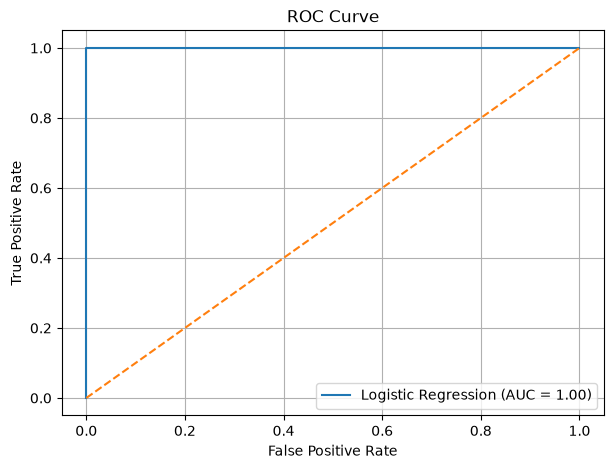

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [10]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

metrics_df = pd.DataFrame(
    list(metrics.items()),
    columns=["Metric", "Score"]
)

metrics_df

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0
4,ROC-AUC,1.0


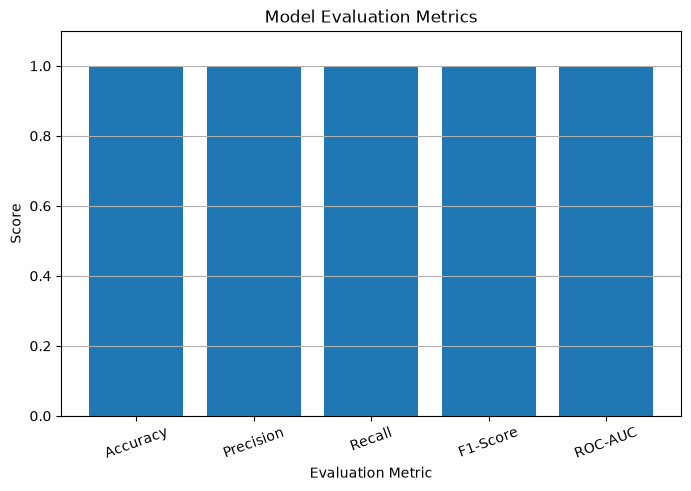

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(metrics_df["Metric"], metrics_df["Score"])

plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Model Evaluation Metrics")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

## Conclusion

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC Curve, and ROC-AUC.

The model achieved a score of 1.00 for all evaluation metrics on the test dataset. The confusion matrix showed 1 true negative and 1 true positive with no false positives or false negatives.

The ROC-AUC score of 1.00 indicates perfect class separation on this test set.

Since the dataset is very small, these results should not be interpreted as evidence of real-world model performance. Larger and more diverse datasets would be required for reliable evaluation.